# 🚗 Used Car Price Prediction

Predicting the resale (selling) price of used cars using regression and
ensemble machine-learning models, based on the
[Vehicle Dataset from CarDekho](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho).

**Pipeline:** Data Cleaning → Feature Engineering → EDA → Model Training →
Model Comparison → Export best model for the Streamlit app.


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

sns.set_style("whitegrid")
%matplotlib inline

RANDOM_STATE = 42

## 2. Load Dataset

The dataset path is relative, so the notebook works whether you run it
locally or on Kaggle/Colab. If you have the real CarDekho CSV, place it at
`data/Car_details_v3.csv` (a synthetic sample is included so the notebook
runs out of the box — see `data/generate_sample_data.py`).

In [2]:
DATA_PATH = "../data/Car_details_v3.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Tata Nexon,2019,203600.0,110669,Diesel,Individual,Manual,Third Owner,23.93 kmpl,1408 CC,92.94 bhp,115Nm@ 3824rpm,4
1,Maruti Swift,2016,139900.0,100777,Diesel,Individual,Automatic,First Owner,18.72 kmpl,944 CC,48.48 bhp,148Nm@ 2146rpm,5
2,Ford Ecosport,2013,135800.0,90977,Petrol,Individual,Manual,First Owner,18.48 kmpl,1257 CC,63.12 bhp,316Nm@ 3000rpm,5
3,Hyundai i20,2016,101900.0,125846,Diesel,Individual,Manual,First Owner,20.44 kmpl,700 CC,51.58 bhp,69Nm@ 1879rpm,7
4,BMW 3 Series,2019,710800.0,22351,Diesel,Individual,Manual,Second Owner,9.9 kmpl,2795 CC,279.55 bhp,189Nm@ 1700rpm,7


In [3]:
print(df.shape)
df.info()

(3000, 13)
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           3000 non-null   str    
 1   year           3000 non-null   int64  
 2   selling_price  3000 non-null   float64
 3   km_driven      3000 non-null   int64  
 4   fuel           3000 non-null   str    
 5   seller_type    3000 non-null   str    
 6   transmission   3000 non-null   str    
 7   owner          3000 non-null   str    
 8   mileage        3000 non-null   str    
 9   engine         3000 non-null   str    
 10  max_power      3000 non-null   str    
 11  torque         3000 non-null   str    
 12  seats          3000 non-null   int64  
dtypes: float64(1), int64(3), str(9)
memory usage: 552.4 KB


In [4]:
df.describe()

,year,selling_price,km_driven,seats
count,3000.000000,3.000000e+03,3000.000000,3000.000000
mean,2013.968333,2.102939e+05,108320.589333,5.798000
std,5.478747,1.686645e+05,40496.288128,1.124107
min,2005.000000,3.000000e+04,500.000000,4.000000
25%,2009.000000,9.477500e+04,79989.750000,5.000000
50%,2014.000000,1.622500e+05,107821.000000,5.000000
75%,2019.000000,2.617500e+05,136172.750000,7.000000
max,2023.000000,1.182300e+06,233291.000000,8.000000


## 3. Data Cleaning & Feature Engineering

- Drop columns that don't add predictive value in their raw form (`name`, `torque`).
- Strip units from `engine`, `max_power`, `mileage` and convert to numeric.
- Impute missing numeric values with the median.
- One-hot encode categorical columns.
- Convert `year` into `age` (more intuitive & robust feature).

In [5]:
df = df.drop(['torque', 'name'], axis=1)

In [6]:
df['engine'] = df['engine'].astype(str).str.replace(' CC', '', regex=False)
df['max_power'] = df['max_power'].astype(str).str.replace(' bhp', '', regex=False)
df['mileage'] = df['mileage'].astype(str).str.replace(' kmpl', '', regex=False).str.replace(' km/kg', '', regex=False)

df['engine'] = pd.to_numeric(df['engine'], errors='coerce')
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

In [7]:
df.isnull().sum()

year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64

In [8]:
for col in ['mileage', 'engine', 'max_power', 'seats']:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64

In [9]:
CATEGORICAL_COLS = ['fuel', 'seller_type', 'transmission', 'owner']
df = pd.get_dummies(df, columns=CATEGORICAL_COLS, drop_first=True)
df.head()

,year,selling_price,km_driven,mileage,engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Third Owner
0,2019,203600.0,110669,23.93,1408,92.94,4,True,False,False,True,False,True,False,False,True
1,2016,139900.0,100777,18.72,944,48.48,5,True,False,False,True,False,False,False,False,False
2,2013,135800.0,90977,18.48,1257,63.12,5,False,False,True,True,False,True,False,False,False
3,2016,101900.0,125846,20.44,700,51.58,7,True,False,False,True,False,True,False,False,False
4,2019,710800.0,22351,9.90,2795,279.55,7,True,False,False,True,False,True,False,True,False


In [10]:
df['age'] = 2026 - df['year']
df = df.drop('year', axis=1)
df.head()

,selling_price,km_driven,mileage,engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Third Owner,age
0,203600.0,110669,23.93,1408,92.94,4,True,False,False,True,False,True,False,False,True,7
1,139900.0,100777,18.72,944,48.48,5,True,False,False,True,False,False,False,False,False,10
2,135800.0,90977,18.48,1257,63.12,5,False,False,True,True,False,True,False,False,False,13
3,101900.0,125846,20.44,700,51.58,7,True,False,False,True,False,True,False,False,False,10
4,710800.0,22351,9.90,2795,279.55,7,True,False,False,True,False,True,False,True,False,7


## 4. Exploratory Data Analysis

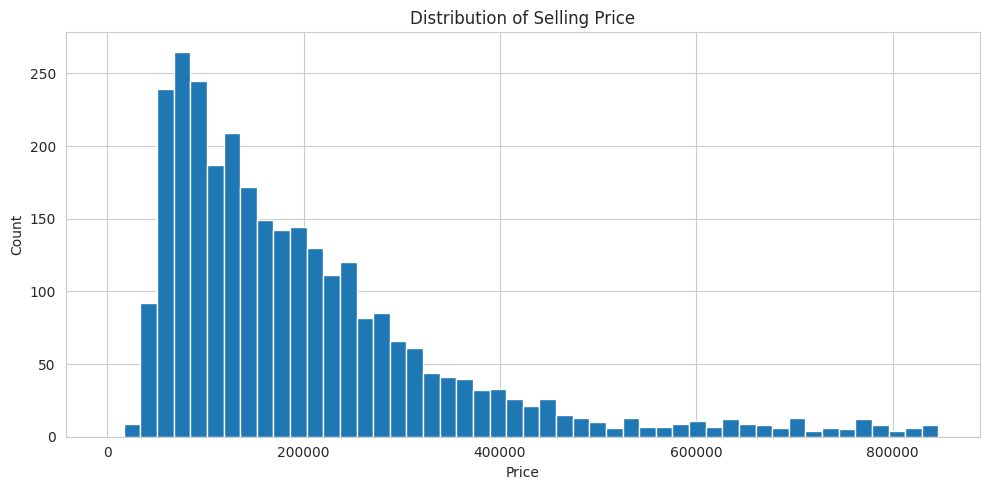

In [11]:
plt.figure(figsize=(10, 5))
plt.hist(df['selling_price'], bins=50, range=(0, df['selling_price'].quantile(0.99)))
plt.title("Distribution of Selling Price")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../assets/price_distribution.png", dpi=150)
plt.show()

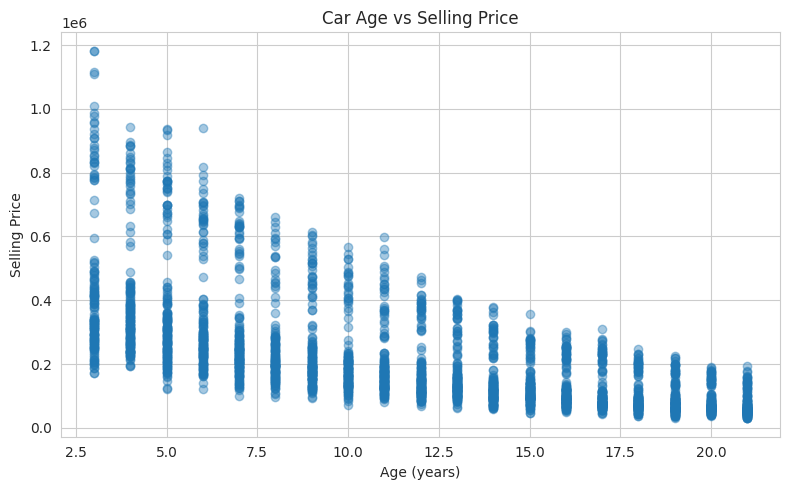

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(df['age'], df['selling_price'], alpha=0.4)
plt.title("Car Age vs Selling Price")
plt.xlabel("Age (years)")
plt.ylabel("Selling Price")
plt.tight_layout()
plt.savefig("../assets/age_vs_price.png", dpi=150)
plt.show()

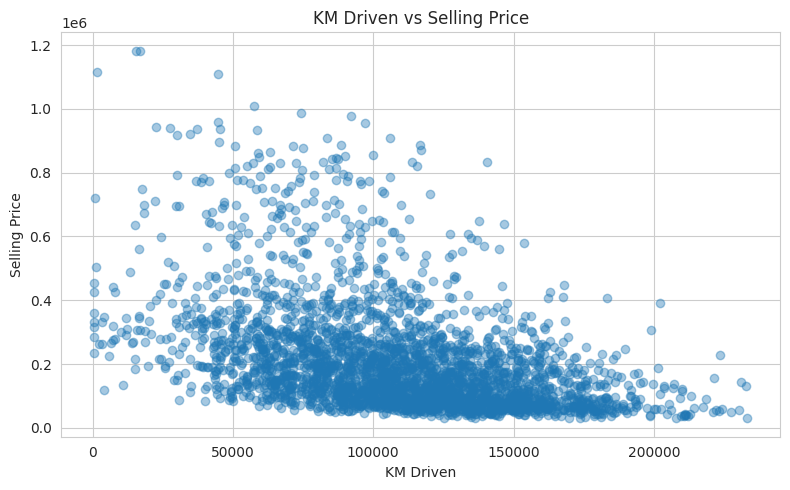

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(df['km_driven'], df['selling_price'], alpha=0.4)
plt.title("KM Driven vs Selling Price")
plt.xlabel("KM Driven")
plt.ylabel("Selling Price")
plt.tight_layout()
plt.savefig("../assets/km_vs_price.png", dpi=150)
plt.show()

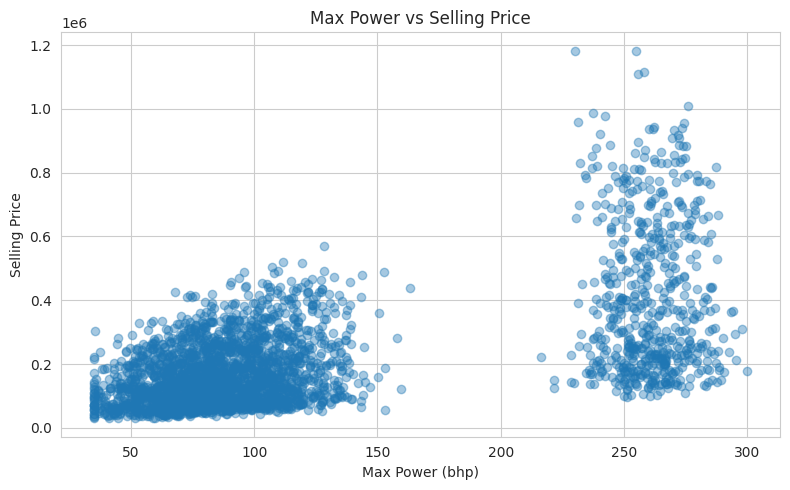

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df['max_power'], df['selling_price'], alpha=0.4)
plt.title("Max Power vs Selling Price")
plt.xlabel("Max Power (bhp)")
plt.ylabel("Selling Price")
plt.tight_layout()
plt.savefig("../assets/power_vs_price.png", dpi=150)
plt.show()

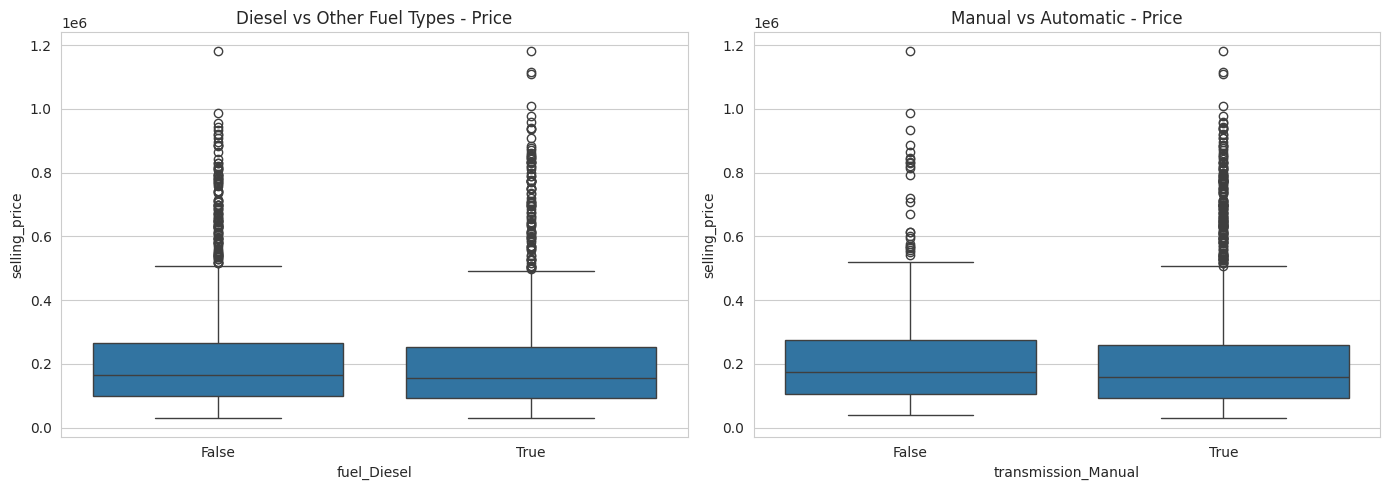

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='fuel_Diesel', y='selling_price', data=df, ax=axes[0])
axes[0].set_title("Diesel vs Other Fuel Types - Price")
sns.boxplot(x='transmission_Manual', y='selling_price', data=df, ax=axes[1])
axes[1].set_title("Manual vs Automatic - Price")
plt.tight_layout()
plt.savefig("../assets/fuel_transmission_vs_price.png", dpi=150)
plt.show()

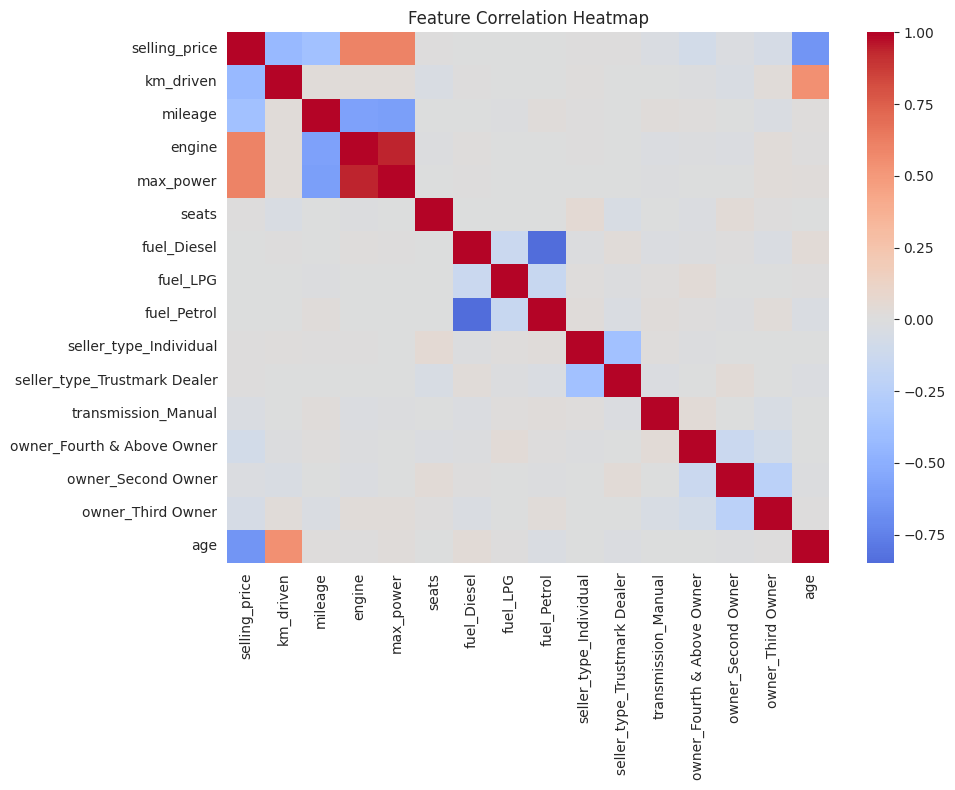

In [16]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("../assets/correlation_heatmap.png", dpi=150)
plt.show()

## 5. Train / Test Split & Scaling

In [17]:
X = df.drop('selling_price', axis=1)
y = df['selling_price']
FEATURE_COLUMNS = X.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE
)
X_train.shape, X_test.shape

((2400, 15), (600, 15))

## 6. Model Training & Comparison

We train several regression models and compare them using **R² score**
and **RMSE** on the held-out test set.

In [18]:
results = []

def add_result(name, y_pred):
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results.append([name, r2, rmse])
    return r2, rmse

trained_models = {}

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
add_result("Linear Regression", lr.predict(X_test))
trained_models["Linear Regression"] = lr

# Polynomial Regression (degree 2)
poly = make_pipeline(PolynomialFeatures(2), LinearRegression())
poly.fit(X_train, y_train)
add_result("Polynomial Regression", poly.predict(X_test))
trained_models["Polynomial Regression"] = poly

# Ridge
ridge = Ridge()
ridge.fit(X_train, y_train)
add_result("Ridge", ridge.predict(X_test))
trained_models["Ridge"] = ridge

# Lasso
lasso = Lasso()
lasso.fit(X_train, y_train)
add_result("Lasso", lasso.predict(X_test))
trained_models["Lasso"] = lasso

# ElasticNet
elastic = ElasticNet()
elastic.fit(X_train, y_train)
add_result("ElasticNet", elastic.predict(X_test))
trained_models["ElasticNet"] = elastic

# Decision Tree
dt = DecisionTreeRegressor(random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
add_result("Decision Tree", dt.predict(X_test))
trained_models["Decision Tree"] = dt

# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
add_result("Random Forest", rf.predict(X_test))
trained_models["Random Forest"] = rf

# KNN
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
add_result("KNN", knn.predict(X_test))
trained_models["KNN"] = knn

# XGBoost
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=RANDOM_STATE,
)
xgb.fit(X_train, y_train)
add_result("XGBoost", xgb.predict(X_test))
trained_models["XGBoost"] = xgb

df_results = pd.DataFrame(results, columns=["Model", "R2 Score", "RMSE"])
df_results = df_results.sort_values(by="R2 Score", ascending=False).reset_index(drop=True)
df_results

,Model,R2 Score,RMSE
0,XGBoost,0.984240,18674.643102
1,Polynomial Regression,0.984139,18734.600495
2,Random Forest,0.968148,26548.938682
3,Decision Tree,0.919776,42133.430116
4,Ridge,0.844148,58726.111738
5,Lasso,0.844099,58735.492005
6,Linear Regression,0.844096,58735.903409
7,KNN,0.840169,59471.181553
8,ElasticNet,0.809232,64972.240101


/tmp/ipykernel_714/1359863707.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x="R2 Score", y="Model", palette="viridis")


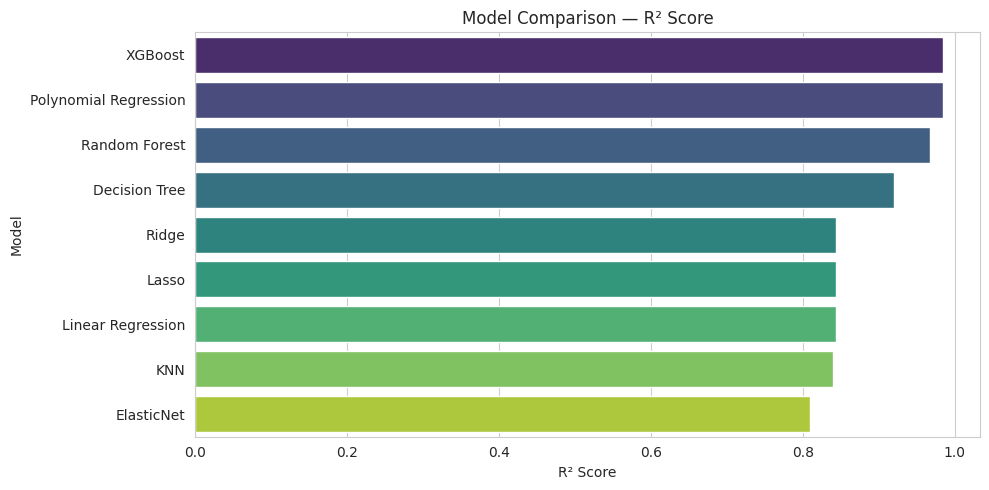

In [19]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_results, x="R2 Score", y="Model", palette="viridis")
plt.title("Model Comparison — R² Score")
plt.xlabel("R² Score")
plt.tight_layout()
plt.savefig("../assets/model_comparison.png", dpi=150)
plt.show()

## 7. Feature Importance (Best Tree-based Model)

Best model: XGBoost


/tmp/ipykernel_714/3151826230.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="mako")


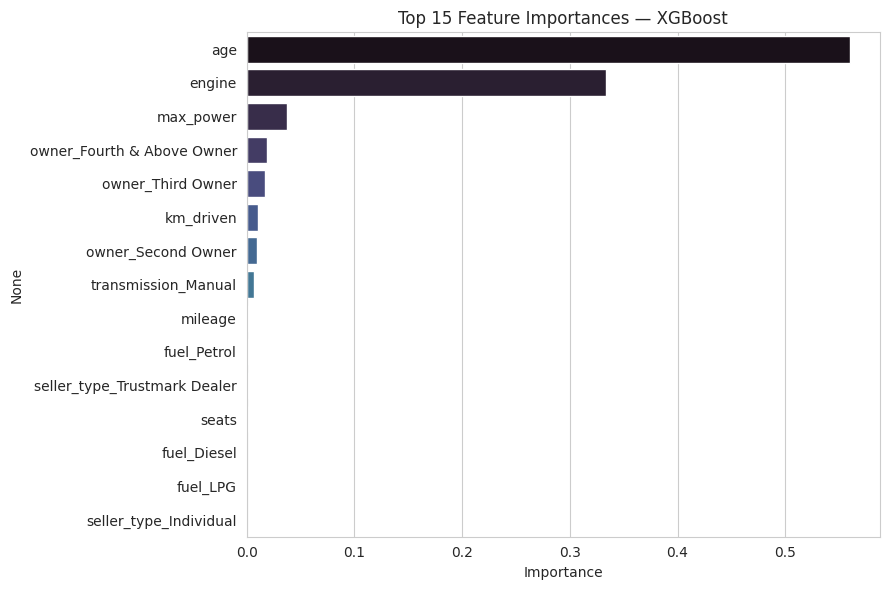

In [20]:
best_model_name = df_results.iloc[0]['Model']
best_model = trained_models[best_model_name]
print("Best model:", best_model_name)

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=FEATURE_COLUMNS)
    importances = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(9, 6))
    sns.barplot(x=importances.values, y=importances.index, palette="mako")
    plt.title(f"Top 15 Feature Importances — {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig("../assets/feature_importance.png", dpi=150)
    plt.show()
else:
    print(f"{best_model_name} does not expose feature_importances_.")

## 8. Baseline Sanity Check: Simple Linear Regression (Age only)

A quick sanity check using a single feature (`age`) shows how much of the
price variation is explained by age alone, compared to the full model.

In [21]:
X_simple = df[['age']]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=RANDOM_STATE
)

simple_lr = LinearRegression()
simple_lr.fit(X_train_s, y_train_s)
pred = simple_lr.predict(X_test_s)

print("Simple Linear Regression (age only)")
print("R2  :", r2_score(y_test_s, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_s, pred)))

Simple Linear Regression (age only)
R2  : 0.4160738755067974
RMSE: 113672.27720543538


## 9. Export the Best Model

Save the best-performing model, the fitted scaler, and the exact feature
column order to `models/`, so the Streamlit app (`app/streamlit_app.py`)
can load and use them directly for inference.

In [22]:
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/best_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(FEATURE_COLUMNS, "../models/feature_columns.pkl")

print(f"Saved '{best_model_name}' to models/best_model.pkl")
print("Saved scaler.pkl and feature_columns.pkl")

Saved 'XGBoost' to models/best_model.pkl
Saved scaler.pkl and feature_columns.pkl
